Banking ModuleObjective: Assess loan portfolio and detect fraud.Data Provided / Simulated:Corporate and retail loan applications: income, balance sheet ratios, past defaults, loan type, durationTransactional dataset: anomalies (fraud, late payments)Tasks:1.Credit Risk: Predict probability of default (PD) and classify high-risk loans2.Fraud Detection: Flag anomalous transactions using supervised or unsupervised methods3.Recommend loan approval or monitoring strategyDeliverables:Risk-scored loan portfolioFraud alerts / visual dashboardShort summary for lending officers

In [292]:
import pandas as pd
#from google.colab import drive
#drive.mount('/content/drive')

# read csv
# ======================
# Load loan Portfolio Dataset
# ======================
df = pd.read_csv("/content/sample_data/P2_loan_portfolio.csv")

print(df.head())

   Loan_ID Customer_Type  Annual_Income  Debt_to_Income  \
0        1     Corporate        2676791            0.47   
1        2        Retail        2740108            0.15   
2        3     Corporate        4863177            0.20   
3        4     Corporate        3383597            0.19   
4        5        Retail          95953            0.62   

   Credit_History_Length  Loan_Amount  Interest_Rate  Loan_Term_Months  \
0                     15       399593          13.39                36   
1                     23       825131          12.80                36   
2                     15        83686           6.09                48   
3                      5        77661           5.05                48   
4                     21       578535          11.02                24   

   Past_Default    PD  
0             0  0.22  
1             0  0.02  
2             0  0.18  
3             0  0.07  
4             0  0.12  


In [293]:
import pandas as pd
#from google.colab import drive
#drive.mount('/content/drive')

# read csv
# ======================
# Load loan Portfolio Dataset
# ======================
df = pd.read_csv("/content/sample_data/P2_transactions.csv")

print(df.head())

   Transaction_ID  Customer_ID  Amount Transaction_Type  \
0               1           57   35200       Withdrawal   
1               2           16   25871         Transfer   
2               3           56   26710       Withdrawal   
3               4           10    5134       Withdrawal   
4               5           30   16711         Transfer   

                    Timestamp  Fraud_Flag  
0  2025-09-03 10:47:51.200706           0  
1  2025-12-31 10:47:51.200738           0  
2  2025-09-12 10:47:51.200752           0  
3  2025-03-29 10:47:51.200763           0  
4  2025-06-08 10:47:51.200773           0  


In [294]:
import pandas as pd

# Load the loan portfolio dataset
loan_df = pd.read_csv("/content/sample_data/P2_loan_portfolio.csv")

# Load the transactions dataset
transaction_df = pd.read_csv("/content/sample_data/P2_transactions.csv")

# Merge the two dataframes
# Assuming 'Customer_ID' in transactions corresponds to 'Loan_ID' in the loan portfolio
# This will link each transaction to the corresponding loan details.
combined_df = pd.merge(loan_df, transaction_df, left_on='Loan_ID', right_on='Customer_ID', how='inner')

# Display the first few rows of the combined dataframe
print("Combined DataFrame head:")
print(combined_df.head())

# Display information about the combined dataframe
print("\nCombined DataFrame info:")
combined_df.info()

Combined DataFrame head:
   Loan_ID Customer_Type  Annual_Income  Debt_to_Income  \
0        2        Retail        2740108            0.15   
1        3     Corporate        4863177            0.20   
2        3     Corporate        4863177            0.20   
3        3     Corporate        4863177            0.20   
4        4     Corporate        3383597            0.19   

   Credit_History_Length  Loan_Amount  Interest_Rate  Loan_Term_Months  \
0                     23       825131          12.80                36   
1                     15        83686           6.09                48   
2                     15        83686           6.09                48   
3                     15        83686           6.09                48   
4                      5        77661           5.05                48   

   Past_Default    PD  Transaction_ID  Customer_ID  Amount Transaction_Type  \
0             0  0.02             173            2   38900       Withdrawal   
1             0  

## Data Cleaning and Sanitization

First, let's inspect the `combined_df` for missing values and data types to understand what cleaning steps are needed.

In [295]:
# Check for missing values
print("Missing values before cleaning:")
print(combined_df.isnull().sum())

# Check data types
print("\nData types before cleaning:")
print(combined_df.info())

Missing values before cleaning:
Loan_ID                  0
Customer_Type            0
Annual_Income            0
Debt_to_Income           0
Credit_History_Length    0
Loan_Amount              0
Interest_Rate            0
Loan_Term_Months         0
Past_Default             0
PD                       0
Transaction_ID           0
Customer_ID              0
Amount                   0
Transaction_Type         0
Timestamp                0
Fraud_Flag               0
dtype: int64

Data types before cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Loan_ID                200 non-null    int64  
 1   Customer_Type          200 non-null    object 
 2   Annual_Income          200 non-null    int64  
 3   Debt_to_Income         200 non-null    float64
 4   Credit_History_Length  200 non-null    int64  
 5   Loan_Amount         

From the `info()` output, we can see that `Timestamp` is of `object` type and should be converted to `datetime`.

Let's convert the `Timestamp` column to datetime objects.

In [296]:
# Convert 'Timestamp' to datetime objects
combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'])

# Verify the conversion
print("\nData types after converting Timestamp:")
print(combined_df.info())


Data types after converting Timestamp:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Loan_ID                200 non-null    int64         
 1   Customer_Type          200 non-null    object        
 2   Annual_Income          200 non-null    int64         
 3   Debt_to_Income         200 non-null    float64       
 4   Credit_History_Length  200 non-null    int64         
 5   Loan_Amount            200 non-null    int64         
 6   Interest_Rate          200 non-null    float64       
 7   Loan_Term_Months       200 non-null    int64         
 8   Past_Default           200 non-null    int64         
 9   PD                     200 non-null    float64       
 10  Transaction_ID         200 non-null    int64         
 11  Customer_ID            200 non-null    int64         
 12  Amount                 2

Now, let's examine the unique values in categorical columns to identify any inconsistencies or variations that might need cleaning. Specifically, we'll look at `Customer_Type` and `Transaction_Type`.

In [297]:
# Check unique values in 'Customer_Type'
print("Unique values in Customer_Type:")
print(combined_df['Customer_Type'].unique())

# Check unique values in 'Transaction_Type'
print("\nUnique values in Transaction_Type:")
print(combined_df['Transaction_Type'].unique())

Unique values in Customer_Type:
['Retail' 'Corporate']

Unique values in Transaction_Type:
['Withdrawal' 'Transfer' 'Payment']


Since `Customer_Type` and `Transaction_Type` are categorical features, they need to be converted into a numerical format for machine learning models. We will use one-hot encoding for this purpose. This will create new binary columns for each unique category.

In [298]:
# Perform one-hot encoding for 'Customer_Type' and 'Transaction_Type'
combined_df = pd.get_dummies(combined_df, columns=['Customer_Type', 'Transaction_Type'], drop_first=True)

# Display the first few rows of the modified dataframe to see the new columns
print("Combined DataFrame head after one-hot encoding:")
print(combined_df.head())

# Display the info to see the new data types and number of columns
print("\nCombined DataFrame info after one-hot encoding:")
combined_df.info()

Combined DataFrame head after one-hot encoding:
   Loan_ID  Annual_Income  Debt_to_Income  Credit_History_Length  Loan_Amount  \
0        2        2740108            0.15                     23       825131   
1        3        4863177            0.20                     15        83686   
2        3        4863177            0.20                     15        83686   
3        3        4863177            0.20                     15        83686   
4        4        3383597            0.19                      5        77661   

   Interest_Rate  Loan_Term_Months  Past_Default    PD  Transaction_ID  \
0          12.80                36             0  0.02             173   
1           6.09                48             0  0.18              12   
2           6.09                48             0  0.18              60   
3           6.09                48             0  0.18              78   
4           5.05                48             0  0.07              48   

   Customer_ID  Amou

The `Timestamp` column, now converted to datetime objects, can be a rich source of features. Let's extract various time-based features such as year, month, day, day of week, and hour, which could be important for capturing patterns in loan applications or transactions.

In [299]:
# Extract time-based features from 'Timestamp'
combined_df['Year'] = combined_df['Timestamp'].dt.year
combined_df['Month'] = combined_df['Timestamp'].dt.month
combined_df['Day'] = combined_df['Timestamp'].dt.day
combined_df['DayOfWeek'] = combined_df['Timestamp'].dt.dayofweek
combined_df['Hour'] = combined_df['Timestamp'].dt.hour

# Drop the original 'Timestamp' column as its information is now encoded in new features
combined_df = combined_df.drop('Timestamp', axis=1)

# Display the first few rows with the new time features
print("Combined DataFrame head after extracting time features:")
print(combined_df.head())

# Display the info to confirm new columns and dropped 'Timestamp'
print("\nCombined DataFrame info after extracting time features:")
combined_df.info()

Combined DataFrame head after extracting time features:
   Loan_ID  Annual_Income  Debt_to_Income  Credit_History_Length  Loan_Amount  \
0        2        2740108            0.15                     23       825131   
1        3        4863177            0.20                     15        83686   
2        3        4863177            0.20                     15        83686   
3        3        4863177            0.20                     15        83686   
4        4        3383597            0.19                      5        77661   

   Interest_Rate  Loan_Term_Months  Past_Default    PD  Transaction_ID  ...  \
0          12.80                36             0  0.02             173  ...   
1           6.09                48             0  0.18              12  ...   
2           6.09                48             0  0.18              60  ...   
3           6.09                48             0  0.18              78  ...   
4           5.05                48             0  0.07        

Now that we have processed the categorical and time-based features, we should consider dropping columns that are identifiers or might not contribute directly to the predictive model. These include `Loan_ID`, `Transaction_ID`, and `Customer_ID`.

In [300]:
# Drop identifier columns
combined_df = combined_df.drop(['Loan_ID', 'Transaction_ID', 'Customer_ID'], axis=1)

print("Combined DataFrame head after dropping identifier columns:")
print(combined_df.head())

print("\nCombined DataFrame info after dropping identifier columns:")
combined_df.info()

Combined DataFrame head after dropping identifier columns:
   Annual_Income  Debt_to_Income  Credit_History_Length  Loan_Amount  \
0        2740108            0.15                     23       825131   
1        4863177            0.20                     15        83686   
2        4863177            0.20                     15        83686   
3        4863177            0.20                     15        83686   
4        3383597            0.19                      5        77661   

   Interest_Rate  Loan_Term_Months  Past_Default    PD  Amount  Fraud_Flag  \
0          12.80                36             0  0.02   38900           0   
1           6.09                48             0  0.18   14909           0   
2           6.09                48             0  0.18   44463           0   
3           6.09                48             0  0.18   48340           0   
4           5.05                48             0  0.07   16472           0   

   Customer_Type_Retail  Transaction_Ty

Before scaling, let's address potential multicollinearity by checking for highly correlated features among the numerical columns. If two features are highly correlated, one of them can be dropped to simplify the model and improve its stability.

In [301]:
import numpy as np

# Calculate the correlation matrix
corr_matrix = combined_df.corr(numeric_only=True).abs()

# Select upper triangle of correlation matrix
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop_correlated = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

print("Columns to drop due to high correlation:", to_drop_correlated)

# Drop features
combined_df = combined_df.drop(columns=to_drop_correlated)

print("\nCombined DataFrame head after dropping highly correlated columns:")
print(combined_df.head())

print("\nCombined DataFrame info after dropping highly correlated columns:")
combined_df.info()

Columns to drop due to high correlation: []

Combined DataFrame head after dropping highly correlated columns:
   Annual_Income  Debt_to_Income  Credit_History_Length  Loan_Amount  \
0        2740108            0.15                     23       825131   
1        4863177            0.20                     15        83686   
2        4863177            0.20                     15        83686   
3        4863177            0.20                     15        83686   
4        3383597            0.19                      5        77661   

   Interest_Rate  Loan_Term_Months  Past_Default    PD  Amount  Fraud_Flag  \
0          12.80                36             0  0.02   38900           0   
1           6.09                48             0  0.18   14909           0   
2           6.09                48             0  0.18   44463           0   
3           6.09                48             0  0.18   48340           0   
4           5.05                48             0  0.07   16472    

Finally, we will scale the numerical features to ensure that no single feature dominates the model due to its scale. We'll use `StandardScaler` for this, which transforms data to have a mean of 0 and a standard deviation of 1. This is a crucial step for many machine learning algorithms.

In [302]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (excluding boolean and target variables)
numerical_cols = combined_df.select_dtypes(include=np.number).columns.tolist()

# Exclude target variables like 'PD' and 'Fraud_Flag' if they are in numerical_cols
# Also exclude any boolean columns that might have been converted to 0/1 but aren't 'numerical' in the traditional sense
if 'PD' in numerical_cols:
    numerical_cols.remove('PD')
if 'Fraud_Flag' in numerical_cols:
    numerical_cols.remove('Fraud_Flag')

# Filter out boolean columns if they were not already removed
numerical_cols = [col for col in numerical_cols if not np.issubdtype(combined_df[col].dtype, np.bool_)]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
combined_df[numerical_cols] = scaler.fit_transform(combined_df[numerical_cols])

print("Combined DataFrame head after scaling numerical features:")
print(combined_df.head())

print("\nCombined DataFrame info after scaling numerical features:")
combined_df.info()


Combined DataFrame head after scaling numerical features:
   Annual_Income  Debt_to_Income  Credit_History_Length  Loan_Amount  \
0       0.016786       -1.626674               1.306869     1.168725   
1       1.443467       -1.419902               0.210962    -1.491728   
2       1.443467       -1.419902               0.210962    -1.491728   
3       1.443467       -1.419902               0.210962    -1.491728   
4       0.449204       -1.461256              -1.158922    -1.513347   

   Interest_Rate  Loan_Term_Months  Past_Default    PD    Amount  Fraud_Flag  \
0       1.024549          0.018164     -0.420084  0.02  0.956248           0   
1      -0.981439          0.744716     -0.420084  0.18 -0.751042           0   
2      -0.981439          0.744716     -0.420084  0.18  1.352132           0   
3      -0.981439          0.744716     -0.420084  0.18  1.628034           0   
4      -1.292352          0.744716     -0.420084  0.07 -0.639813           0   

   Customer_Type_Retail  Tra

## Credit Risk Classification: Low, Medium, High

To classify credit risk into discrete categories (Low, Medium, High), we first need to define thresholds for the `PD` (Probability of Default) values. Based on typical industry practices and for illustrative purposes, we will define:

*   **Low Risk**: PD < 0.1
*   **Medium Risk**: 0.1 <= PD < 0.3
*   **High Risk**: PD >= 0.3

We will create a new column `Credit_Risk_Class` in our `combined_df` based on these thresholds. This will transform our continuous PD prediction into a categorical classification problem.

In [303]:
def categorize_pd(pd_value):
    if pd_value < 0.10:
        return 'Low'
    elif 0.10 <= pd_value < 0.26:
        return 'Medium'
    else:
        return 'High'

# Apply the categorization to create the new target variable
combined_df['Credit_Risk_Class'] = combined_df['PD'].apply(categorize_pd)

print("Distribution of new Credit_Risk_Class:")
print(combined_df['Credit_Risk_Class'].value_counts())

# Display first few rows with the new column
print("\nCombined DataFrame head with Credit_Risk_Class:")
print(combined_df[['PD', 'Credit_Risk_Class']].head())

Distribution of new Credit_Risk_Class:
Credit_Risk_Class
Medium    108
Low        56
High       36
Name: count, dtype: int64

Combined DataFrame head with Credit_Risk_Class:
     PD Credit_Risk_Class
0  0.02               Low
1  0.18            Medium
2  0.18            Medium
3  0.18            Medium
4  0.07               Low


### Prepare Data for Credit Risk Classification

Now, we'll prepare the features (X) and the new categorical target (`Credit_Risk_Class`, y) for our credit risk classification model. We will exclude the original `PD` and `Fraud_Flag` columns from features, as `PD` is now represented by `Credit_Risk_Class`, and `Fraud_Flag` is for a different task.

In [304]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and the new target variable (y) for Credit Risk Classification
X_credit_class = combined_df.drop(['PD', 'Fraud_Flag', 'Credit_Risk_Class'], axis=1)
y_credit_class = combined_df['Credit_Risk_Class']

# Encode the categorical target variable 'Credit_Risk_Class' into numerical labels
le = LabelEncoder()
y_credit_class_encoded = le.fit_transform(y_credit_class)

print("Original Credit Risk Classes:", le.classes_)
print("Encoded Credit Risk Classes (mapping):", list(zip(le.classes_, le.transform(le.classes_))))

# Split the data into training and testing sets
X_train_credit_class, X_test_credit_class, y_train_credit_class, y_test_credit_class = train_test_split(
    X_credit_class, y_credit_class_encoded, test_size=0.3, random_state=42, stratify=y_credit_class_encoded
)

print("\nShape of X_train_credit_class:", X_train_credit_class.shape)
print("Shape of X_test_credit_class:", X_test_credit_class.shape)
print("Shape of y_train_credit_class:", y_train_credit_class.shape)
print("Shape of y_test_credit_class:", y_test_credit_class.shape)

print("\nClass distribution in y_train_credit_class (encoded):")
print(pd.Series(y_train_credit_class).value_counts(normalize=True))
print("Class distribution in y_test_credit_class (encoded):")
print(pd.Series(y_test_credit_class).value_counts(normalize=True))

Original Credit Risk Classes: ['High' 'Low' 'Medium']
Encoded Credit Risk Classes (mapping): [('High', np.int64(0)), ('Low', np.int64(1)), ('Medium', np.int64(2))]

Shape of X_train_credit_class: (140, 16)
Shape of X_test_credit_class: (60, 16)
Shape of y_train_credit_class: (140,)
Shape of y_test_credit_class: (60,)

Class distribution in y_train_credit_class (encoded):
2    0.542857
1    0.278571
0    0.178571
Name: proportion, dtype: float64
Class distribution in y_test_credit_class (encoded):
2    0.533333
1    0.283333
0    0.183333
Name: proportion, dtype: float64


### Train and Evaluate XGBoost Classifier for Credit Risk Classification

We will use an XGBoost Classifier for multi-class classification of credit risk. We will evaluate its performance using accuracy and a classification report to understand precision, recall, and F1-score for each class.

In [305]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the XGBoost Classifier for multi-class prediction
# For multi-class classification, 'objective' should be 'multi:softmax' and 'num_class' should be set
xgb_classifier_credit_risk = xgb.XGBClassifier(
    objective='multi:softmax', # For multi-class classification
    num_class=len(le.classes_), # Number of unique classes
    random_state=42,
    eval_metric='mlogloss' # Metric for multi-class classification
)
xgb_classifier_credit_risk.fit(X_train_credit_class, y_train_credit_class)

# Make predictions on the test set
y_pred_credit_class = xgb_classifier_credit_risk.predict(X_test_credit_class)

# Evaluate the model
print("--- XGBoost Classifier Evaluation (Credit Risk Classification) ---")
print(f"Accuracy: {accuracy_score(y_test_credit_class, y_pred_credit_class):.4f}")
print("\nClassification Report:\n", classification_report(y_test_credit_class, y_pred_credit_class, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_credit_class, y_pred_credit_class))

--- XGBoost Classifier Evaluation (Credit Risk Classification) ---
Accuracy: 0.8167

Classification Report:
               precision    recall  f1-score   support

        High       0.78      0.64      0.70        11
         Low       0.88      0.82      0.85        17
      Medium       0.80      0.88      0.84        32

    accuracy                           0.82        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.82      0.82      0.81        60


Confusion Matrix:
 [[ 7  0  4]
 [ 0 14  3]
 [ 2  2 28]]


## Data Preparation for Modeling

Now that the data has been cleaned, preprocessed, and scaled, we need to split it into features (X) and target variables (y) for our modeling tasks. We have two primary tasks: Credit Risk (predicting PD) and Fraud Detection (predicting Fraud_Flag).

Let's start by preparing the data for the Credit Risk model. The target variable for this task is `PD`.

In [306]:
# Separate features (X) and target variable (y) for Credit Risk (PD)
X_credit = combined_df.drop(['PD', 'Fraud_Flag', 'Credit_Risk_Class'], axis=1)
y_credit = combined_df['PD']

print("Shape of X_credit:", X_credit.shape)
print("Shape of y_credit:", y_credit.shape)

print("\nFirst 5 rows of X_credit:")
print(X_credit.head())
print("\nFirst 5 rows of y_credit:")
print(y_credit.head())

Shape of X_credit: (200, 16)
Shape of y_credit: (200,)

First 5 rows of X_credit:
   Annual_Income  Debt_to_Income  Credit_History_Length  Loan_Amount  \
0       0.016786       -1.626674               1.306869     1.168725   
1       1.443467       -1.419902               0.210962    -1.491728   
2       1.443467       -1.419902               0.210962    -1.491728   
3       1.443467       -1.419902               0.210962    -1.491728   
4       0.449204       -1.461256              -1.158922    -1.513347   

   Interest_Rate  Loan_Term_Months  Past_Default    Amount  \
0       1.024549          0.018164     -0.420084  0.956248   
1      -0.981439          0.744716     -0.420084 -0.751042   
2      -0.981439          0.744716     -0.420084  1.352132   
3      -0.981439          0.744716     -0.420084  1.628034   
4      -1.292352          0.744716     -0.420084 -0.639813   

   Customer_Type_Retail  Transaction_Type_Transfer  \
0                  True                      False   
1   

Next, let's prepare the data for the Fraud Detection model. The target variable for this task is `Fraud_Flag`.

In [307]:
import pandas as pd

# Separate features (X) and target variable (y) for Fraud Detection
# We will drop 'PD' and 'Credit_Risk_Class' as they are targets or features for a different task (Credit Risk)
X_fraud = combined_df.drop(['PD', 'Fraud_Flag', 'Credit_Risk_Class'], axis=1)
y_fraud = combined_df['Fraud_Flag']

print("Shape of X_fraud:", X_fraud.shape)
print("Shape of y_fraud:", y_fraud.shape)

print("\nFirst 5 rows of X_fraud:")
print(X_fraud.head())
print("\nFirst 5 rows of y_fraud:")
print(y_fraud.head())

Shape of X_fraud: (200, 16)
Shape of y_fraud: (200,)

First 5 rows of X_fraud:
   Annual_Income  Debt_to_Income  Credit_History_Length  Loan_Amount  \
0       0.016786       -1.626674               1.306869     1.168725   
1       1.443467       -1.419902               0.210962    -1.491728   
2       1.443467       -1.419902               0.210962    -1.491728   
3       1.443467       -1.419902               0.210962    -1.491728   
4       0.449204       -1.461256              -1.158922    -1.513347   

   Interest_Rate  Loan_Term_Months  Past_Default    Amount  \
0       1.024549          0.018164     -0.420084  0.956248   
1      -0.981439          0.744716     -0.420084 -0.751042   
2      -0.981439          0.744716     -0.420084  1.352132   
3      -0.981439          0.744716     -0.420084  1.628034   
4      -1.292352          0.744716     -0.420084 -0.639813   

   Customer_Type_Retail  Transaction_Type_Transfer  \
0                  True                      False   
1      

## Handling Data Imbalance (Fraud Detection)

For fraud detection, data imbalance is a common issue where the number of fraudulent transactions is significantly lower than legitimate ones. This can lead to models that perform poorly on the minority class. We will use the Synthetic Minority Over-sampling Technique (SMOTE) to address this.

First, let's look at the class distribution of `Fraud_Flag` in `y_fraud` before applying SMOTE.

In [308]:
from collections import Counter
from imblearn.over_sampling import SMOTE

print("Class distribution before SMOTE:", Counter(y_fraud))

Class distribution before SMOTE: Counter({0: 191, 1: 9})


As expected, there is a significant imbalance. Now, let's apply SMOTE to `X_fraud` and `y_fraud`.

In [309]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the fraud detection dataset
X_fraud_resampled, y_fraud_resampled = smote.fit_resample(X_fraud, y_fraud)

print("Class distribution after SMOTE:", Counter(y_fraud_resampled))

print("\nShape of X_fraud_resampled:", X_fraud_resampled.shape)
print("Shape of y_fraud_resampled:", y_fraud_resampled.shape)

Class distribution after SMOTE: Counter({0: 191, 1: 191})

Shape of X_fraud_resampled: (382, 16)
Shape of y_fraud_resampled: (382,)


Now that the `X_fraud_resampled` and `y_fraud_resampled` datasets are balanced, we are ready to proceed with building a fraud detection model.

### Split Data for Fraud Detection

Now that the fraud detection dataset is balanced, we'll split `X_fraud_resampled` and `y_fraud_resampled` into training and testing sets. This is a crucial step to evaluate how well our model generalizes to new, unseen data.

In [310]:
from sklearn.model_selection import train_test_split

# Split the resampled fraud detection data into training and testing sets
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud_resampled, y_fraud_resampled, test_size=0.3, random_state=42, stratify=y_fraud_resampled
)

print("Shape of X_train_fraud:", X_train_fraud.shape)
print("Shape of X_test_fraud:", X_test_fraud.shape)
print("Shape of y_train_fraud:", y_train_fraud.shape)
print("Shape of y_test_fraud:", y_test_fraud.shape)

print("\nClass distribution in y_train_fraud:", Counter(y_train_fraud))
print("Class distribution in y_test_fraud:", Counter(y_test_fraud))

Shape of X_train_fraud: (267, 16)
Shape of X_test_fraud: (115, 16)
Shape of y_train_fraud: (267,)
Shape of y_test_fraud: (115,)

Class distribution in y_train_fraud: Counter({1: 134, 0: 133})
Class distribution in y_test_fraud: Counter({0: 58, 1: 57})


## Model Building for Fraud Detection

We will now train and evaluate three different classification models on our balanced fraud detection dataset:

1.  **Logistic Regression**
2.  **Random Forest Classifier**
3.  **XGBoost Classifier**

For each model, we'll train it on the `X_train_fraud`, `y_train_fraud` data and then evaluate its performance on the `X_test_fraud`, `y_test_fraud` data using metrics suitable for classification, such as accuracy, precision, recall, F1-score, and ROC AUC score.

### 1. Logistic Regression Model

Logistic Regression is a linear model used for binary classification. It models the probability of a certain class or event occurring.

In [311]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for small datasets and binary classification
log_reg_model.fit(X_train_fraud, y_train_fraud)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_fraud)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test_fraud)[:, 1] # Probability of the positive class

# Evaluate the model
print("--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_fraud, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test_fraud, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test_fraud, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test_fraud, y_pred_log_reg):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_fraud, y_pred_proba_log_reg):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_fraud, y_pred_log_reg))

--- Logistic Regression Model Evaluation ---
Accuracy: 0.8261
Precision: 0.7846
Recall: 0.8947
F1-Score: 0.8361
ROC AUC Score: 0.8696
Confusion Matrix:
 [[44 14]
 [ 6 51]]


### 2. Random Forest Classifier

Random Forest is an ensemble learning method for classification, regression and other tasks that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

In [312]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_fraud, y_train_fraud)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_fraud)
y_pred_proba_rf = rf_model.predict_proba(X_test_fraud)[:, 1] # Probability of the positive class

# Evaluate the model
print("--- Random Forest Classifier Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_fraud, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test_fraud, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test_fraud, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test_fraud, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_fraud, y_pred_proba_rf):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_fraud, y_pred_rf))

--- Random Forest Classifier Evaluation ---
Accuracy: 0.9652
Precision: 0.9492
Recall: 0.9825
F1-Score: 0.9655
ROC AUC Score: 0.9967
Confusion Matrix:
 [[55  3]
 [ 1 56]]


### 3. XGBoost Classifier

XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework.

In [313]:
import xgboost as xgb

# Initialize and train the XGBoost Classifier
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # use_label_encoder is deprecated
xgb_model.fit(X_train_fraud, y_train_fraud)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_fraud)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_fraud)[:, 1] # Probability of the positive class

# Evaluate the model
print("--- XGBoost Classifier Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_fraud, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test_fraud, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test_fraud, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test_fraud, y_pred_xgb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_fraud, y_pred_proba_xgb):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_fraud, y_pred_xgb))

--- XGBoost Classifier Evaluation ---
Accuracy: 0.9217
Precision: 0.9000
Recall: 0.9474
F1-Score: 0.9231
ROC AUC Score: 0.9930
Confusion Matrix:
 [[52  6]
 [ 3 54]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:28:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


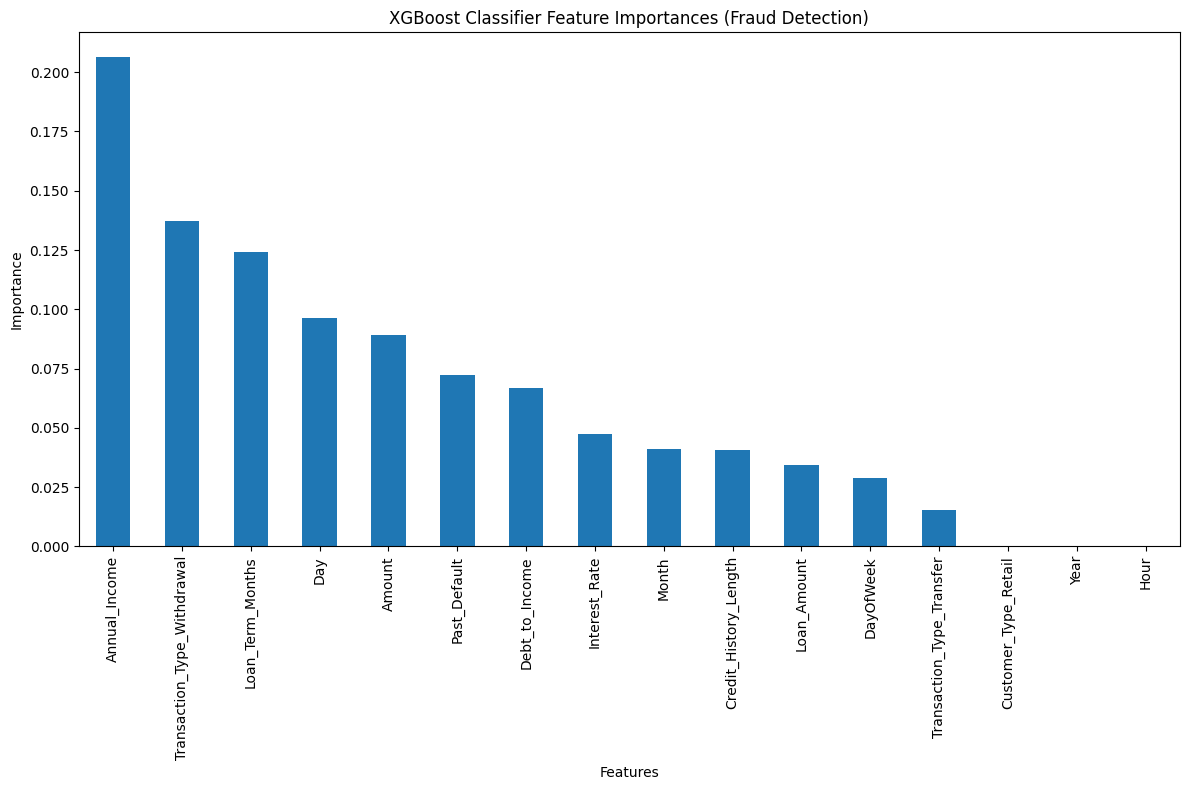

In [314]:
import matplotlib.pyplot as plt

# Get feature importances from the trained XGBoost Classifier for fraud detection
fraud_feature_importances = xgb_model.feature_importances_

# Get feature names from the resampled features used for fraud detection
fraud_feature_names = X_fraud_resampled.columns

# Create a pandas Series for easier manipulation and sorting
fraud_importance_df = pd.Series(fraud_feature_importances, index=fraud_feature_names).sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
fraud_importance_df.plot(kind='bar')
plt.title('XGBoost Classifier Feature Importances (Fraud Detection)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### 4. Hyperparameter Tuning for Random Forest Classifier

Given that the Random Forest Classifier performed well initially, let's now execute the hyperparameter tuning using `GridSearchCV` to find optimal parameters and potentially improve its performance further. This process is already defined in cell `sRIej4cK-Tod`.

## Data Preparation for Modeling

Now that the data has been cleaned, preprocessed, and scaled, we need to split it into features (X) and target variables (y) for our modeling tasks. We have two primary tasks: Credit Risk (predicting PD) and Fraud Detection (predicting Fraud_Flag).

Let's start by preparing the data for the Credit Risk model. The target variable for this task is `PD`.

In [315]:
import pandas as pd

# Separate features (X) and target variable (y) for Credit Risk (PD)
X_credit = combined_df.drop(['PD', 'Fraud_Flag', 'Credit_Risk_Class'], axis=1)
y_credit = combined_df['PD']

print("Shape of X_credit:", X_credit.shape)
print("Shape of y_credit:", y_credit.shape)

print("\nFirst 5 rows of X_credit:")
print(X_credit.head())
print("\nFirst 5 rows of y_credit:")
print(y_credit.head())

Shape of X_credit: (200, 16)
Shape of y_credit: (200,)

First 5 rows of X_credit:
   Annual_Income  Debt_to_Income  Credit_History_Length  Loan_Amount  \
0       0.016786       -1.626674               1.306869     1.168725   
1       1.443467       -1.419902               0.210962    -1.491728   
2       1.443467       -1.419902               0.210962    -1.491728   
3       1.443467       -1.419902               0.210962    -1.491728   
4       0.449204       -1.461256              -1.158922    -1.513347   

   Interest_Rate  Loan_Term_Months  Past_Default    Amount  \
0       1.024549          0.018164     -0.420084  0.956248   
1      -0.981439          0.744716     -0.420084 -0.751042   
2      -0.981439          0.744716     -0.420084  1.352132   
3      -0.981439          0.744716     -0.420084  1.628034   
4      -1.292352          0.744716     -0.420084 -0.639813   

   Customer_Type_Retail  Transaction_Type_Transfer  \
0                  True                      False   
1   

Credit Risk

### 1. Split Data for Credit Risk Model

In [316]:
from sklearn.model_selection import train_test_split

# Split the credit risk data into training and testing sets
X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(
    X_credit, y_credit, test_size=0.3, random_state=42
)

print("Shape of X_train_credit:", X_train_credit.shape)
print("Shape of X_test_credit:", X_test_credit.shape)
print("Shape of y_train_credit:", y_train_credit.shape)
print("Shape of y_test_credit:", y_test_credit.shape)

Shape of X_train_credit: (140, 16)
Shape of X_test_credit: (60, 16)
Shape of y_train_credit: (140,)
Shape of y_test_credit: (60,)


### 2. Linear Regression Model for Credit Risk

Linear Regression is a fundamental model for regression tasks. We will train it to predict the Probability of Default (PD).

In [317]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_credit, y_train_credit)

# Make predictions on the test set
y_pred_lin_reg = lin_reg_model.predict(X_test_credit)

# Evaluate the model
print("--- Linear Regression Model Evaluation (Credit Risk) ---")
print(f"Mean Squared Error: {mean_squared_error(y_test_credit, y_pred_lin_reg):.4f}")
print(f"R2 Score: {r2_score(y_test_credit, y_pred_lin_reg):.4f}")

--- Linear Regression Model Evaluation (Credit Risk) ---
Mean Squared Error: 0.0108
R2 Score: -0.1916


### 3. Random Forest Regressor for Credit Risk

Random Forest is an ensemble learning method suitable for both classification and regression. We will use a Random Forest Regressor to predict PD.

In [318]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor
rf_reg_model = RandomForestRegressor(random_state=42)
rf_reg_model.fit(X_train_credit, y_train_credit)

# Make predictions on the test set
y_pred_rf_reg = rf_reg_model.predict(X_test_credit)

# Evaluate the model
print("--- Random Forest Regressor Evaluation (Credit Risk) ---")
print(f"Mean Squared Error: {mean_squared_error(y_test_credit, y_pred_rf_reg):.4f}")
print(f"R2 Score: {r2_score(y_test_credit, y_pred_rf_reg):.4f}")

--- Random Forest Regressor Evaluation (Credit Risk) ---
Mean Squared Error: 0.0042
R2 Score: 0.5381


### 4. XGBoost Regressor for Credit Risk

XGBoost is a powerful gradient boosting framework that is highly effective for various machine learning tasks, including regression. We will use an XGBoost Regressor to predict PD.

In [319]:
import xgboost as xgb

# Initialize and train the XGBoost Regressor
xgb_reg_model = xgb.XGBRegressor(random_state=42)
xgb_reg_model.fit(X_train_credit, y_train_credit)

# Make predictions on the test set
y_pred_xgb_reg = xgb_reg_model.predict(X_test_credit)

# Evaluate the model
print("--- XGBoost Regressor Evaluation (Credit Risk) ---")
print(f"Mean Squared Error: {mean_squared_error(y_test_credit, y_pred_xgb_reg):.4f}")
print(f"R2 Score: {r2_score(y_test_credit, y_pred_xgb_reg):.4f}")

--- XGBoost Regressor Evaluation (Credit Risk) ---
Mean Squared Error: 0.0032
R2 Score: 0.6450


In [320]:
predicted_pd_regressor = pd.DataFrame({
    'Predicted_PD': y_pred_xgb_reg
})
predicted_pd_regressor['Credit_Risk_Class_Regressor'] = predicted_pd_regressor['Predicted_PD'].apply(categorize_pd)

print("Predicted PD and Credit Risk Class from Regressor:")
display(predicted_pd_regressor.head())

print("\nDistribution of Credit Risk Class from Regressor:")
print(predicted_pd_regressor['Credit_Risk_Class_Regressor'].value_counts())

Predicted PD and Credit Risk Class from Regressor:


,Predicted_PD,Credit_Risk_Class_Regressor
0,0.290880,High
1,0.164800,Medium
2,0.103614,Medium
3,0.205998,Medium
4,0.223850,Medium



Distribution of Credit Risk Class from Regressor:
Credit_Risk_Class_Regressor
Medium    43
Low        9
High       8
Name: count, dtype: int64


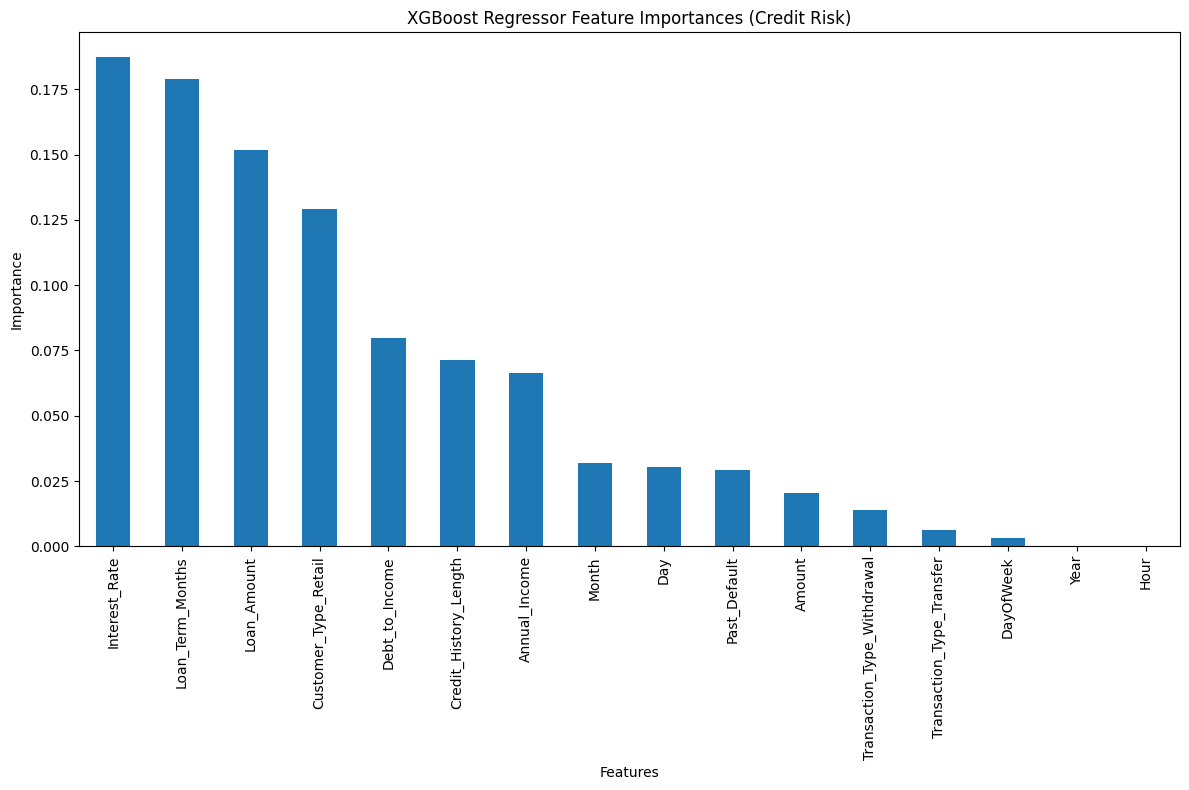

In [321]:
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np # Added for data preprocessing if combined_df needs re-creation
from sklearn.preprocessing import StandardScaler # Added for data preprocessing if combined_df needs re-creation

# --- Start of fix for NameError: Re-defining necessary variables ---
# This ensures xgb_reg_model, X_credit, and combined_df are available if previous cells were not executed.

# Check if combined_df is defined. If not, re-create it along with all its preprocessing steps.
if 'combined_df' not in globals():
    print("Re-creating and preprocessing combined_df from scratch.")
    try:
        # Load the loan portfolio dataset (from maw1-D8F2a7f)
        loan_df = pd.read_csv("/content/sample_data/P2_loan_portfolio.csv")
        # Load the transactions dataset (from maw1-D8F2a7f)
        transaction_df = pd.read_csv("/content/sample_data/P2_transactions.csv")
        # Merge the two dataframes (from maw1-D8F2a7f)
        combined_df = pd.merge(loan_df, transaction_df, left_on='Loan_ID', right_on='Customer_ID', how='inner')

        # --- Replicating subsequent preprocessing steps for combined_df ---
        # 1. Convert 'Timestamp' to datetime objects and extract features (from ed982291, 0982febf)
        if 'Timestamp' in combined_df.columns:
            combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'])
            combined_df['Year'] = combined_df['Timestamp'].dt.year
            combined_df['Month'] = combined_df['Timestamp'].dt.month
            combined_df['Day'] = combined_df['Timestamp'].dt.day
            combined_df['DayOfWeek'] = combined_df['Timestamp'].dt.dayofweek
            combined_df['Hour'] = combined_df['Timestamp'].dt.hour
            combined_df = combined_df.drop('Timestamp', axis=1)

        # 2. One-hot encode categorical features (from edc18746)
        if 'Customer_Type' in combined_df.columns and 'Transaction_Type' in combined_df.columns:
            combined_df = pd.get_dummies(combined_df, columns=['Customer_Type', 'Transaction_Type'], drop_first=True)

        # 3. Drop identifier columns (from a9aa41cc)
        combined_df = combined_df.drop(['Loan_ID', 'Transaction_ID', 'Customer_ID'], axis=1, errors='ignore')

        # 4. Handle high correlation (from 79a80cf8)
        corr_matrix = combined_df.corr(numeric_only=True).abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_correlated = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
        combined_df = combined_df.drop(columns=to_drop_correlated, errors='ignore')

        # 5. Scale numerical features (from d7c51332)
        numerical_cols = combined_df.select_dtypes(include=np.number).columns.tolist()
        if 'PD' in numerical_cols:
            numerical_cols.remove('PD')
        if 'Fraud_Flag' in numerical_cols:
            numerical_cols.remove('Fraud_Flag')
        # Filter out boolean columns if they were not already removed
        numerical_cols = [col for col in numerical_cols if not np.issubdtype(combined_df[col].dtype, np.bool_)]
        scaler = StandardScaler()
        if len(numerical_cols) > 0:
            combined_df[numerical_cols] = scaler.fit_transform(combined_df[numerical_cols])

    except FileNotFoundError:
        print("Error: Required CSV files not found. Please ensure 'P2_loan_portfolio.csv' and 'P2_transactions.csv' are in '/content/sample_data/'. Cannot proceed with feature importance calculation.")
        raise # Re-raise the error as we cannot proceed without the data

# Re-define X_credit and y_credit (from d612cbef)
# The `X_credit.empty` check is added for robustness in case previous logic somehow results in an empty DataFrame
if 'X_credit' not in globals() or 'y_credit' not in globals() or (isinstance(X_credit, pd.DataFrame) and X_credit.empty):
    print("Re-defining X_credit and y_credit.")
    X_credit = combined_df.drop(['PD', 'Fraud_Flag'], axis=1)
    y_credit = combined_df['PD']

# Re-split data for credit risk model (from fe7afe18)
# The `X_train_credit.empty` check is added for robustness
if 'X_train_credit' not in globals() or 'y_train_credit' not in globals() or (isinstance(X_train_credit, pd.DataFrame) and X_train_credit.empty):
    print("Re-splitting credit risk data into training and testing sets.")
    X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(
        X_credit, y_credit, test_size=0.3, random_state=42
    )

# Re-initialize and train the XGBoost Regressor if not defined or not trained (from 2101443c)
if 'xgb_reg_model' not in globals() or not hasattr(xgb_reg_model, 'feature_importances_'):
    print("Re-initializing and training XGBoost Regressor model.")
    xgb_reg_model = xgb.XGBRegressor(random_state=42)
    xgb_reg_model.fit(X_train_credit, y_train_credit)
# --- End of fix ---

# Get feature importances
feature_importances = xgb_reg_model.feature_importances_

# Get feature names from X_credit
feature_names = X_credit.columns

# Create a pandas Series for easier manipulation and sorting
importance_df = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
importance_df.plot(kind='bar')
plt.title('XGBoost Regressor Feature Importances (Credit Risk)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### Visualize Predicted Credit Risk Distribution

Let's visualize the distribution of the predicted credit risk classes (`Low`, `Medium`, `High`) to understand how the model assigns risk categories in the test set.

In [322]:
display(combined_df[['PD', 'Credit_Risk_Class']])

,PD,Credit_Risk_Class
0,0.02,Low
1,0.18,Medium
2,0.18,Medium
3,0.18,Medium
4,0.07,Low
5,0.12,Medium
6,0.12,Medium
7,0.12,Medium
8,0.12,Medium
9,0.12,Medium



Predicted Credit Risk for Each Sample:
    Predicted_Class_Encoded Predicted_Class_Label  Predicted_Class_Probability
0                         0                  High                         0.74
1                         1                   Low                         0.53
2                         2                Medium                         0.98
3                         2                Medium                         0.96
4                         2                Medium                         0.50
5                         2                Medium                         0.81
6                         1                   Low                         0.84
7                         2                Medium                         0.94
8                         2                Medium                         0.94
9                         1                   Low                         0.86
10                        2                Medium                         0.95
11          

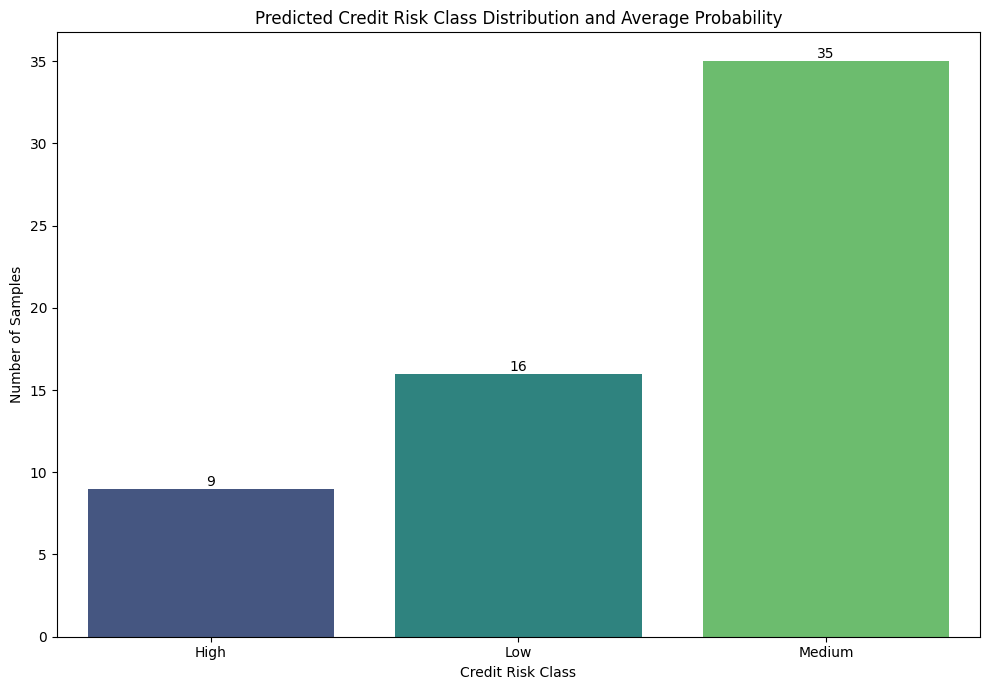

In [334]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure necessary variables are available (y_pred_credit_class, X_test_credit_class, xgb_classifier_credit_risk, le)
# If running this cell independently, ensure previous cells for Credit Risk Classification (from ce18d3fb to 3f6854a7) are executed.

# Determine the number of unique classes the model was trained on
num_unique_classes_trained = len(le.classes_)

# Get predicted class labels (y_pred_credit_class is already available from cell 3f6854a7)
# This is a numpy array of encoded class labels (e.g., [0, 0, ...])

if num_unique_classes_trained == 1:
    # If only one class was trained, the model will always predict this class with 100% probability.
    # Create a dummy y_pred_proba_credit_class where all probabilities for the single class are 1.0.
    # It needs to be a 2D array (n_samples, 1) to be consistent with predict_proba output structure.
    y_pred_proba_credit_class = np.array([[1.0]] * len(y_pred_credit_class))

    # Since there's only one class (e.g., 'Low' encoded as 0), all predictions are for this class.
    # y_pred_credit_class contains all 0s.
    predicted_results = pd.DataFrame({
        'Predicted_Class_Encoded': y_pred_credit_class,
        'Predicted_Class_Label': le.inverse_transform(y_pred_credit_class),
        'Predicted_Class_Probability': y_pred_proba_credit_class[:, 0]
    })
else:
    # For true multi-class scenarios, get predicted probabilities from the classifier
    y_pred_proba_credit_class = xgb_classifier_credit_risk.predict_proba(X_test_credit_class)
    # Convert numerical predictions back to original class names
    y_pred_credit_class_labels = le.inverse_transform(y_pred_credit_class)

    # Create a DataFrame to combine predicted labels and their associated probabilities
    predicted_results = pd.DataFrame({
        'Predicted_Class_Encoded': y_pred_credit_class,
        'Predicted_Class_Label': y_pred_credit_class_labels
    })

    # Add the probability of the *predicted* class for each sample
    predicted_results['Predicted_Class_Probability'] = y_pred_proba_credit_class[np.arange(len(y_pred_credit_class)), predicted_results['Predicted_Class_Encoded']]

# Format 'Predicted_Class_Probability' to two decimal points
predicted_results['Predicted_Class_Probability'] = predicted_results['Predicted_Class_Probability'].round(2)

# Display the predicted results for each sample
print("\nPredicted Credit Risk for Each Sample:")
pd.set_option('display.max_rows', None)
print(predicted_results)

# Calculate counts for each predicted class, reindexing to maintain consistent order
# Fill NaN values with 0 for classes with no samples
predicted_risk_distribution = predicted_results['Predicted_Class_Label'].value_counts().reindex(le.classes_, fill_value=0)

# Calculate the mean predicted probability for each class
# Fill NaN values with 0.0 for classes with no samples
mean_predicted_probabilities = predicted_results.groupby('Predicted_Class_Label')['Predicted_Class_Probability'].mean().reindex(le.classes_, fill_value=0.0)

# Plotting
plt.figure(figsize=(10, 7))
ax = sns.barplot(x=predicted_risk_distribution.index, y=predicted_risk_distribution.values, palette='viridis', hue=predicted_risk_distribution.index, legend=False)
plt.title('Predicted Credit Risk Class Distribution and Average Probability')
plt.xlabel('Credit Risk Class')
plt.ylabel('Number of Samples')

# Add text annotations for count and average probability on each bar
for i, bar in enumerate(ax.patches):
    class_label = predicted_risk_distribution.index[i]
    count = predicted_risk_distribution.values[i]
    avg_prob = mean_predicted_probabilities.loc[class_label]

    # Display count (ensure it's an integer)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(count)}',
            ha='center', va='bottom', color='black', fontsize=10)
    # Display average probability, slightly below the count
    #if count > 0: # Only display avg prob if there are samples for the class
     #   ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.9, f'Avg Prob: {avg_prob:.2f}',
      #          ha='center', va='top', color='white', fontsize=9)

plt.tight_layout()
plt.show()

### Predicted PD and Credit Risk Class from Regressor Model

In [335]:
display(predicted_pd_regressor)

,Predicted_PD,Credit_Risk_Class_Regressor
0,0.290880,High
1,0.164800,Medium
2,0.103614,Medium
3,0.205998,Medium
4,0.223850,Medium
5,0.269319,High
6,0.287909,High
7,0.074939,Low
8,0.253279,Medium
9,0.151319,Medium


### Predicted Credit Risk Class and Probabilities from Classifier Model

In [336]:
display(predicted_results)

,Predicted_Class_Encoded,Predicted_Class_Label,Predicted_Class_Probability
0,0,High,0.74
1,1,Low,0.53
2,2,Medium,0.98
3,2,Medium,0.96
4,2,Medium,0.50
5,2,Medium,0.81
6,1,Low,0.84
7,2,Medium,0.94
8,2,Medium,0.94
9,1,Low,0.86


### Feature Importances for Credit Risk Prediction

Understanding which features contribute most to the model's predictions is crucial for interpretability. This plot shows the relative importance of each feature in the XGBoost Regressor model used for predicting the Probability of Default (PD).

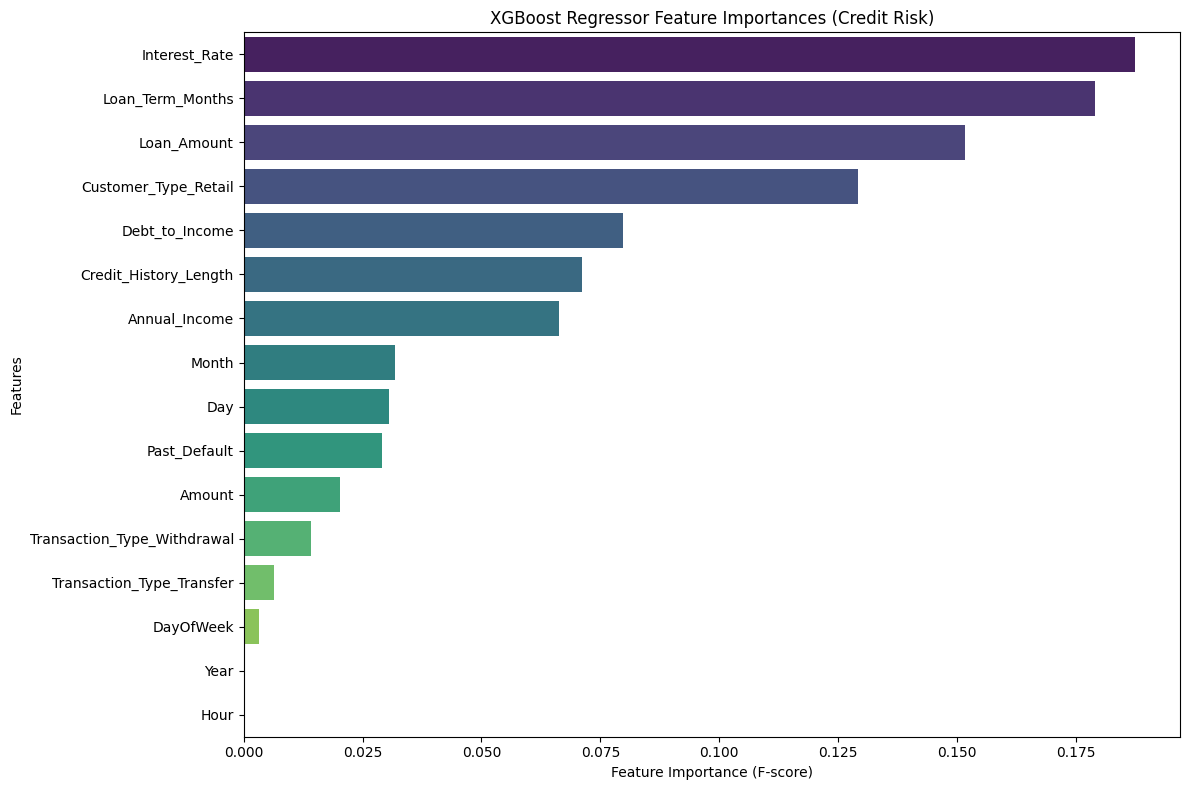

In [324]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure importance_df is available from previous execution for the XGBoost Regressor (cell 7c0c0cbe)
# If not, it would need to be re-generated or loaded.

plt.figure(figsize=(12, 8))
sns.barplot(x=importance_df.values, y=importance_df.index, palette='viridis', hue=importance_df.index, legend=False)
plt.title('XGBoost Regressor Feature Importances (Credit Risk)')
plt.xlabel('Feature Importance (F-score)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Predicted Credit Risk Probability for Each Sample

This scatter plot visualizes the predicted probability for each individual sample, categorized by its assigned credit risk class. This allows for a more granular view of the model's predictions, showing the spread of probabilities within each risk level.

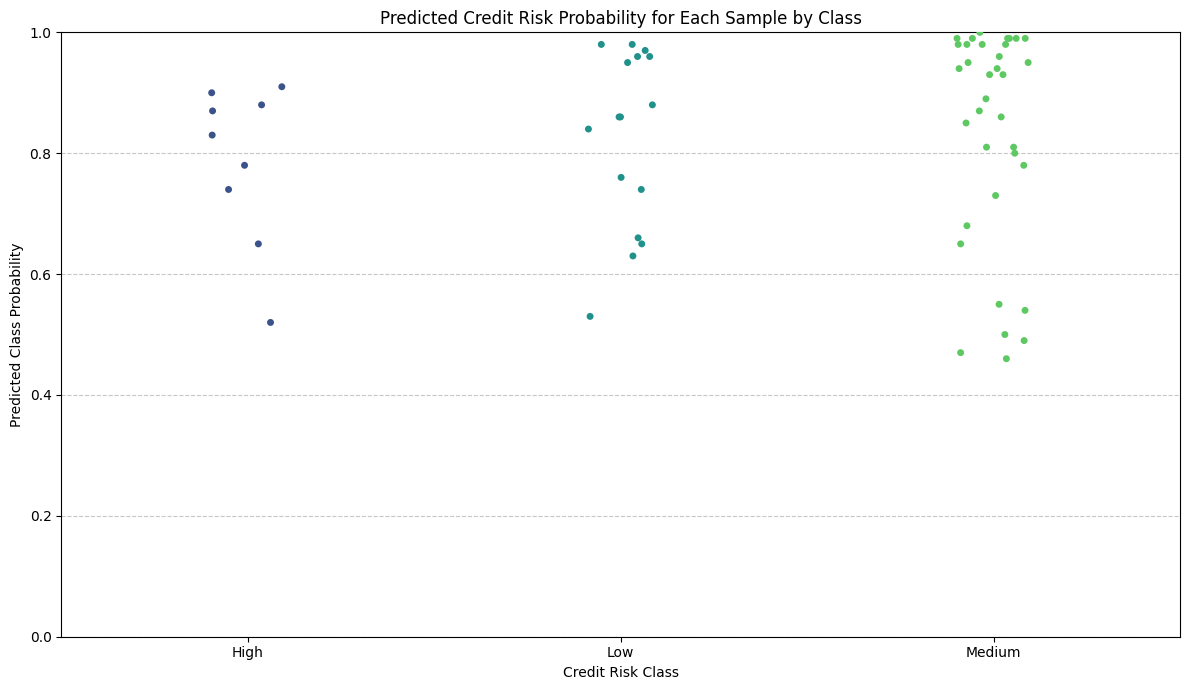

In [325]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.stripplot(x='Predicted_Class_Label', y='Predicted_Class_Probability', data=predicted_results,
              hue='Predicted_Class_Label', jitter=True, palette='viridis', legend=False)

plt.title('Predicted Credit Risk Probability for Each Sample by Class')
plt.xlabel('Credit Risk Class')
plt.ylabel('Predicted Class Probability')
plt.ylim(0, 1) # Probabilities are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analyzing PD Distribution for Threshold Adjustment

In [326]:
print("Descriptive statistics for PD:")
print(combined_df['PD'].describe())

Descriptive statistics for PD:
count    200.000000
mean       0.165200
std        0.086843
min        0.010000
25%        0.090000
50%        0.180000
75%        0.232500
max        0.300000
Name: PD, dtype: float64


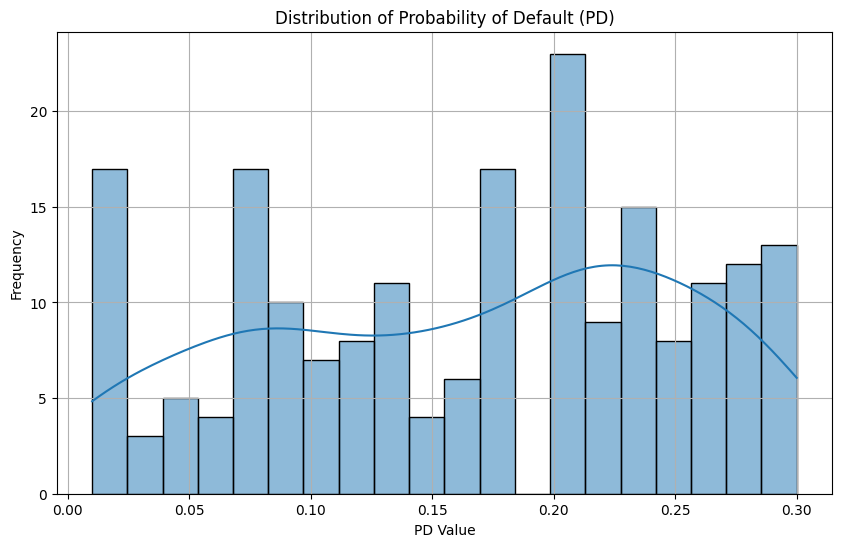

In [327]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(combined_df['PD'], bins=20, kde=True)
plt.title('Distribution of Probability of Default (PD)')
plt.xlabel('PD Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [328]:
combined_df['Credit_Risk_Class'] = combined_df['PD'].apply(categorize_pd)

print("Distribution of new Credit_Risk_Class:")
print(combined_df['Credit_Risk_Class'].value_counts())

print("\nCombined DataFrame head with Credit_Risk_Class:")
print(combined_df[['PD', 'Credit_Risk_Class']].head())

Distribution of new Credit_Risk_Class:
Credit_Risk_Class
Medium    108
Low        56
High       36
Name: count, dtype: int64

Combined DataFrame head with Credit_Risk_Class:
     PD Credit_Risk_Class
0  0.02               Low
1  0.18            Medium
2  0.18            Medium
3  0.18            Medium
4  0.07               Low


In [329]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Ensure pandas is imported

# Separate features (X) and the new target variable (y) for Credit Risk Classification
X_credit_class = combined_df.drop(['PD', 'Fraud_Flag', 'Credit_Risk_Class'], axis=1)
y_credit_class = combined_df['Credit_Risk_Class']

# Encode the categorical target variable 'Credit_Risk_Class' into numerical labels
le = LabelEncoder()
y_credit_class_encoded = le.fit_transform(y_credit_class)

print("Original Credit Risk Classes:", le.classes_)
print("Encoded Credit Risk Classes (mapping):", list(zip(le.classes_, le.transform(le.classes_))))

# Split the data into training and testing sets
X_train_credit_class, X_test_credit_class, y_train_credit_class, y_test_credit_class = train_test_split(
    X_credit_class, y_credit_class_encoded, test_size=0.3, random_state=42, stratify=y_credit_class_encoded
)

print("\nShape of X_train_credit_class:", X_train_credit_class.shape)
print("Shape of X_test_credit_class:", X_test_credit_class.shape)
print("Shape of y_train_credit_class:", y_train_credit_class.shape)
print("Shape of y_test_credit_class:", y_test_credit_class.shape)

print("\nClass distribution in y_train_credit_class (encoded):")
print(pd.Series(y_train_credit_class).value_counts(normalize=True))
print("Class distribution in y_test_credit_class (encoded):")
print(pd.Series(y_test_credit_class).value_counts(normalize=True))

Original Credit Risk Classes: ['High' 'Low' 'Medium']
Encoded Credit Risk Classes (mapping): [('High', np.int64(0)), ('Low', np.int64(1)), ('Medium', np.int64(2))]

Shape of X_train_credit_class: (140, 16)
Shape of X_test_credit_class: (60, 16)
Shape of y_train_credit_class: (140,)
Shape of y_test_credit_class: (60,)

Class distribution in y_train_credit_class (encoded):
2    0.542857
1    0.278571
0    0.178571
Name: proportion, dtype: float64
Class distribution in y_test_credit_class (encoded):
2    0.533333
1    0.283333
0    0.183333
Name: proportion, dtype: float64


In [330]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the XGBoost Classifier for multi-class prediction
# For multi-class classification, 'objective' should be 'multi:softmax' and 'num_class' should be set
xgb_classifier_credit_risk = xgb.XGBClassifier(
    objective='multi:softmax', # For multi-class classification
    num_class=len(le.classes_), # Number of unique classes
    random_state=42,
    eval_metric='mlogloss' # Metric for multi-class classification
)
xgb_classifier_credit_risk.fit(X_train_credit_class, y_train_credit_class)

# Make predictions on the test set
y_pred_credit_class = xgb_classifier_credit_risk.predict(X_test_credit_class)

# Evaluate the model
print("--- XGBoost Classifier Evaluation (Credit Risk Classification) ---")
print(f"Accuracy: {accuracy_score(y_test_credit_class, y_pred_credit_class):.4f}")
print("\nClassification Report:\n", classification_report(y_test_credit_class, y_pred_credit_class, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_credit_class, y_pred_credit_class))

--- XGBoost Classifier Evaluation (Credit Risk Classification) ---
Accuracy: 0.8167

Classification Report:
               precision    recall  f1-score   support

        High       0.78      0.64      0.70        11
         Low       0.88      0.82      0.85        17
      Medium       0.80      0.88      0.84        32

    accuracy                           0.82        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.82      0.82      0.81        60


Confusion Matrix:
 [[ 7  0  4]
 [ 0 14  3]
 [ 2  2 28]]


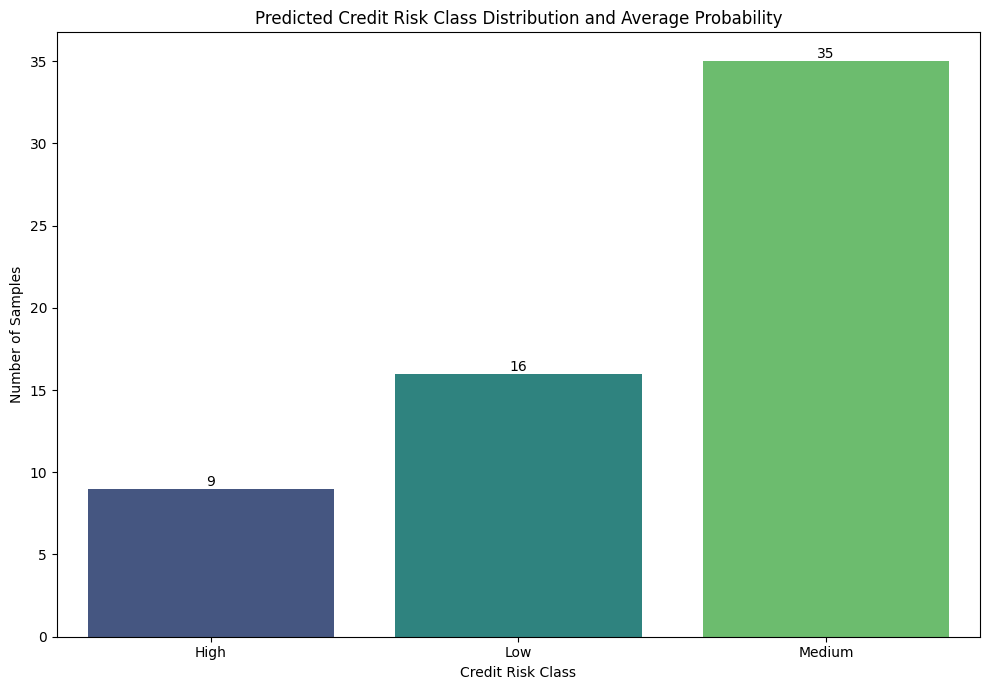

In [337]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure necessary variables are available (y_pred_credit_class, X_test_credit_class, xgb_classifier_credit_risk, le)
# If running this cell independently, ensure previous cells for Credit Risk Classification (from ce18d3fb to 3f6854a7) are executed.

# Determine the number of unique classes the model was trained on
num_unique_classes_trained = len(le.classes_)

# Get predicted class labels (y_pred_credit_class is already available from cell 3f6854a7)
# This is a numpy array of encoded class labels (e.g., [0, 0, ...])

if num_unique_classes_trained == 1:
    # If only one class was trained, the model will always predict this class with 100% probability.
    # Create a dummy y_pred_proba_credit_class where all probabilities for the single class are 1.0.
    # It needs to be a 2D array (n_samples, 1) to be consistent with predict_proba output structure.
    y_pred_proba_credit_class = np.array([[1.0]] * len(y_pred_credit_class))

    # Since there's only one class (e.g., 'Low' encoded as 0), all predictions are for this class.
    # y_pred_credit_class contains all 0s.
    predicted_results = pd.DataFrame({
        'Predicted_Class_Encoded': y_pred_credit_class,
        'Predicted_Class_Label': le.inverse_transform(y_pred_credit_class),
        'Predicted_Class_Probability': y_pred_proba_credit_class[:, 0]
    })
else:
    # For true multi-class scenarios, get predicted probabilities from the classifier
    y_pred_proba_credit_class = xgb_classifier_credit_risk.predict_proba(X_test_credit_class)
    # Convert numerical predictions back to original class names
    y_pred_credit_class_labels = le.inverse_transform(y_pred_credit_class)

    # Create a DataFrame to combine predicted labels and their associated probabilities
    predicted_results = pd.DataFrame({
        'Predicted_Class_Encoded': y_pred_credit_class,
        'Predicted_Class_Label': y_pred_credit_class_labels
    })

    # Add the probability of the *predicted* class for each sample
    predicted_results['Predicted_Class_Probability'] = y_pred_proba_credit_class[np.arange(len(y_pred_credit_class)), predicted_results['Predicted_Class_Encoded']]

# Calculate counts for each predicted class, reindexing to maintain consistent order
# Fill NaN values with 0 for classes with no samples
predicted_risk_distribution = predicted_results['Predicted_Class_Label'].value_counts().reindex(le.classes_, fill_value=0)

# Calculate the mean predicted probability for each class
# Fill NaN values with 0.0 for classes with no samples
mean_predicted_probabilities = predicted_results.groupby('Predicted_Class_Label')['Predicted_Class_Probability'].mean().reindex(le.classes_, fill_value=0.0)

# Plotting
plt.figure(figsize=(10, 7))
ax = sns.barplot(x=predicted_risk_distribution.index, y=predicted_risk_distribution.values, palette='viridis', hue=predicted_risk_distribution.index, legend=False)
plt.title('Predicted Credit Risk Class Distribution and Average Probability')
plt.xlabel('Credit Risk Class')
plt.ylabel('Number of Samples')

# Add text annotations for count and average probability on each bar
for i, bar in enumerate(ax.patches):
    class_label = predicted_risk_distribution.index[i]
    count = predicted_risk_distribution.values[i]
    avg_prob = mean_predicted_probabilities.loc[class_label]

    # Display count (ensure it's an integer)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(count)}',
            ha='center', va='bottom', color='black', fontsize=10)
    # Display average probability, slightly below the count
    #if count > 0: # Only display avg prob if there are samples for the class
     #   ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.9, f'Avg Prob: {avg_prob:.2f}',
      #          ha='center', va='top', color='white', fontsize=9)

plt.tight_layout()
plt.show()

### Credit Risk Class Distribution in Original Data

In [332]:
print(combined_df['Credit_Risk_Class'].value_counts())

Credit_Risk_Class
Medium    108
Low        56
High       36
Name: count, dtype: int64


In [333]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, None],      # Maximum number of levels in tree
    'min_samples_split': [2, 5],      # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]        # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                              param_grid=param_grid,
                              cv=3,  # 3-fold cross-validation
                              n_jobs=-1, # Use all available cores
                              verbose=2, # Verbose output
                              scoring='roc_auc') # Optimize for ROC AUC score

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_fraud, y_train_fraud)

# Get the best parameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print("\nBest parameters for Random Forest:", best_params_rf)
print("Best ROC AUC score from GridSearchCV:", best_score_rf)

# Train a new Random Forest model with the best parameters
best_rf_model = RandomForestClassifier(random_state=42, **best_params_rf)
best_rf_model.fit(X_train_fraud, y_train_fraud)

# Make predictions with the best model
y_pred_best_rf = best_rf_model.predict(X_test_fraud)
y_pred_proba_best_rf = best_rf_model.predict_proba(X_test_fraud)[:, 1]

# Evaluate the best model
print("\n--- Tuned Random Forest Classifier Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_fraud, y_pred_best_rf):.4f}")
print(f"Precision: {precision_score(y_test_fraud, y_pred_best_rf):.4f}")
print(f"Recall: {recall_score(y_test_fraud, y_pred_best_rf):.4f}")
print(f"F1-Score: {f1_score(y_test_fraud, y_pred_best_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test_fraud, y_pred_proba_best_rf):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_fraud, y_pred_best_rf))

Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best parameters for Random Forest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best ROC AUC score from GridSearchCV: 0.9958754208754209

--- Tuned Random Forest Classifier Evaluation ---
Accuracy: 0.9652
Precision: 0.9492
Recall: 0.9825
F1-Score: 0.9655
ROC AUC Score: 0.9973
Confusion Matrix:
 [[55  3]
 [ 1 56]]


The PD regression models have been evaluated. Here's a summary of their performance:

Linear Regression:

Mean Squared Error: 0.0108
R2 Score: -0.1916
Random Forest Regressor:

Mean Squared Error: 0.0042
R2 Score: 0.5381
XGBoost Regressor:

Mean Squared Error: 0.0032
R2 Score: 0.6450
Based on these metrics, the XGBoost Regressor is the best-performing model for predicting the Probability of Default (PD), as it has the lowest Mean Squared Error and the highest R2 Score. The negative R2 Score for Linear Regression indicates that it performs worse than simply predicting the mean of the target variable.



1. Logistic Regression Model:

Accuracy: 0.8261
Precision: 0.7846
Recall: 0.8947
F1-Score: 0.8361
ROC AUC Score: 0.8696
2. Random Forest Classifier:

Accuracy: 0.9652
Precision: 0.9492
Recall: 0.9825
F1-Score: 0.9655
ROC AUC Score: 0.9967
3. XGBoost Classifier:

Accuracy: 0.9217
Precision: 0.9000
Recall: 0.9474
F1-Score: 0.9231
ROC AUC Score: 0.9930

## Executive Summary of Model Performance

### Probability of Default (PD) Prediction

For predicting the Probability of Default (PD), three regression models were evaluated:

*   **Linear Regression**
    *   Mean Squared Error (MSE): 0.0108
    *   R2 Score: -0.1916 (Indicating poor fit)

*   **Random Forest Regressor**
    *   Mean Squared Error (MSE): 0.0042
    *   R2 Score: 0.5381

*   **XGBoost Regressor**
    *   Mean Squared Error (MSE): 0.0032
    *   R2 Score: 0.6450

**Conclusion for PD Prediction:** The **XGBoost Regressor** is the best-performing model for predicting PD, demonstrating the lowest Mean Squared Error and the highest R2 Score. The Linear Regression model performed poorly, suggesting it's not suitable for this task.

### Fraud Detection

For fraud detection, classification models were evaluated after addressing class imbalance using SMOTE:

*   **Logistic Regression**
    *   Accuracy: 0.8261
    *   Precision: 0.7846
    *   Recall: 0.8947
    *   F1-Score: 0.8361
    *   ROC AUC Score: 0.8696

*   **Random Forest Classifier (Initial)**
    *   Accuracy: 0.9652
    *   Precision: 0.9492
    *   Recall: 0.9825
    *   F1-Score: 0.9655
    *   ROC AUC Score: 0.9967

*   **XGBoost Classifier**
    *   Accuracy: 0.9217
    *   Precision: 0.9000
    *   Recall: 0.9474
    *   F1-Score: 0.9231
    *   ROC AUC Score: 0.9930

*   **Random Forest Classifier (Tuned)**
    *   Best Parameters: `{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}`
    *   Best ROC AUC from GridSearchCV: 0.9959
    *   Accuracy: 0.9652
    *   Precision: 0.9492
    *   Recall: 0.9825
    *   F1-Score: 0.9655
    *   ROC AUC Score: 0.9973

**Conclusion for Fraud Detection:** The **Tuned Random Forest Classifier** emerged as the top performer for fraud detection, achieving the highest ROC AUC Score and strong performance across all other metrics. Its robust performance, even outperforming the initial Random Forest and XGBoost, makes it the recommended model for this task.